In [12]:
import subprocess
import time
def setup():
    !pip install -q langchain_community langchain_ollama langchain_classic langchain_chroma pypdf rank_bm25 langchain_core flashrank google-colab    
    !apt-get -qq update && apt-get -qq install -y zstd
    !curl -fsSL https://ollama.com/install.sh | sh
    
    subprocess.Popen(
        ["ollama", "serve"],
        stdout=open("/tmp/ollama.log", "w"),
        stderr=subprocess.STDOUT
    )
    time.sleep(5)
    
    !ollama pull qwen3-embedding:0.6b

setup()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 MB 22.4 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 9.8 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 9.4 MB/s eta 0:00:00
ERROR: Cannot install langchain-classic==1.0.0, langchain-classic==1.0.1, langchain-classic==1.0.2, langchain-classic==1.0.3, langchain-classic==1.0.4, langchain-classic==1.0.5, langchain-classic==1.0.6, langchain-classic==1.0.7, langchain-classic==1.0.8, langchain-community==0.0.1 and langchain_core because these package versions have conflicting dependencies.
ERROR: ResolutionI

### 1. Récupération des données de ChromaDB

In [14]:
import os
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings

# Chemin sur colab contenant le fichier chroma.sqlite3
from google.colab import drive
drive.mount('/content/drive')

persist_dir = '/content/drive/MyDrive/Chatbot_Loi_Travail/chroma_db'



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Initialisation du modèle embeddings
embedding_model = OllamaEmbeddings(model="qwen3-embedding:0.6b")

# Chargement de la base de données ChromaDB
vector_store = Chroma(
    persist_directory=persist_dir,
    embedding_function=embedding_model
)


print(f"Nombre de documents chargés : {vector_store._collection.count()}")

Nombre de documents chargés : 588


In [16]:
type(vector_store)

langchain_chroma.vectorstores.Chroma

In [17]:
article1 = vector_store._collection.get(limit= 1)

print("============== Article 1: ================== \n")
print(article1)
print("\n\n Type article 1 : ", type(article1))

============== Article 1: ================== 

{'ids': ['af9358b8-2f05-451c-9771-17ce3c16308e'], 'embeddings': None, 'documents': ["Article premier Les dispositions de la présente loi s'appliquent aux personnes liées par un contrat de travail quels que soient ses modalités d'exécution, la nature de la rémunération et le mode de son paiement qu'il prévoit et la nature de l'entreprise dans laquelle il s'exécute, notamment les entreprises industrielles, commerciales, artisanales et les exploitations agricoles et forestières et leurs dépendances. Elles s'appliquent également aux entreprises et établissements à caractère industriel, commercial ou agricole relevant de l'Etat et des collectivités locales, aux coopératives, sociétés civiles, syndicats, associations et groupements de toute nature. Les dispositions de la présente loi s'appliquent également aux employeurs exerçant une profession libérale, au secteur des services et, de manière générale, aux personnes liées par un contrat de trava

In [18]:
from langchain_core.documents import Document

# extraire tous les articles dans chromadb sous forme de texte brut
# Car ChromaDB stocke les vecteurs (embeddings) mais n'a pas de moteur BM25 intégré

raw_data = vector_store._collection.get()
documents = []
for content, metadata in zip(raw_data['documents'], raw_data['metadatas']):
    documents.append(Document(page_content=content, metadata=metadata))

print(type(documents))



<class 'list'>


### 2. Keyword Search : BM25 retriever

In [19]:
from langchain_community.retrievers import BM25Retriever
bm25_retriever = BM25Retriever.from_documents(documents, k= 5)



In [20]:
query = "Quelle est la durée de congé de maternité pour une femme enceinte ?"
print(type(query))
bm25_docs = bm25_retriever.invoke(query)

print(len(bm25_docs))
print("Résultats BM25 \n")
for doc in bm25_docs[:2]:
    print(f"[{doc.metadata.get('article_no')}] : {doc.page_content[:150]}...\n")
    
print(type(bm25_docs))

<class 'str'>
5
Résultats BM25 

[Article 152] : Article 152 La salariée en état de grossesse attesté par certificat médical dispose d'un congé de maternité de quatorze semaines, sauf stipulations pl...

[Article 154] : Article 154 La salariée a le droit de suspendre le contrat de travail pendant une période qui commence sept semaines avant la date présumée de l'accou...

<class 'list'>


### 3. Semantic_search (vectoriel): 

In [21]:
chroma_retriever = vector_store.as_retriever(search_kwargs={"k": 5}) # search_type = cosine similarity (default!)

In [22]:
chroma_docs = chroma_retriever.invoke(query)
print(type(chroma_docs))

print("=== Résultats Chroma  ===")
for doc in chroma_docs[:2]:
    print(f"[{doc.metadata.get('article_no')}] : {doc.page_content[:150]}...\n")
    


<class 'list'>
=== Résultats Chroma  ===
[Article 152] : Article 152 La salariée en état de grossesse attesté par certificat médical dispose d'un congé de maternité de quatorze semaines, sauf stipulations pl...

[Article 154] : Article 154 La salariée a le droit de suspendre le contrat de travail pendant une période qui commence sept semaines avant la date présumée de l'accou...



### 4. combinaison des scores RRF

On va regrouper les deux listes de résultats de recherche :

"bm25_docs" et "chroma_docs" 

avec la méthode de fusion Reciprocal Rank Fusion (RRF) afin d'obtenir un classement final plus précis. 

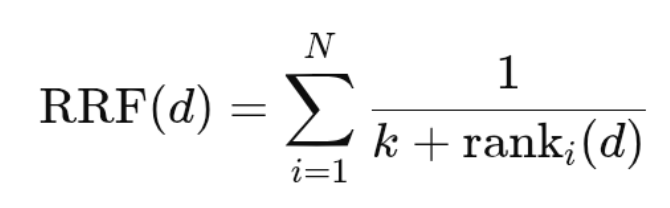

![reciprocal rank fusion.jpeg](<attachment:reciprocal rank fusion.jpeg>)
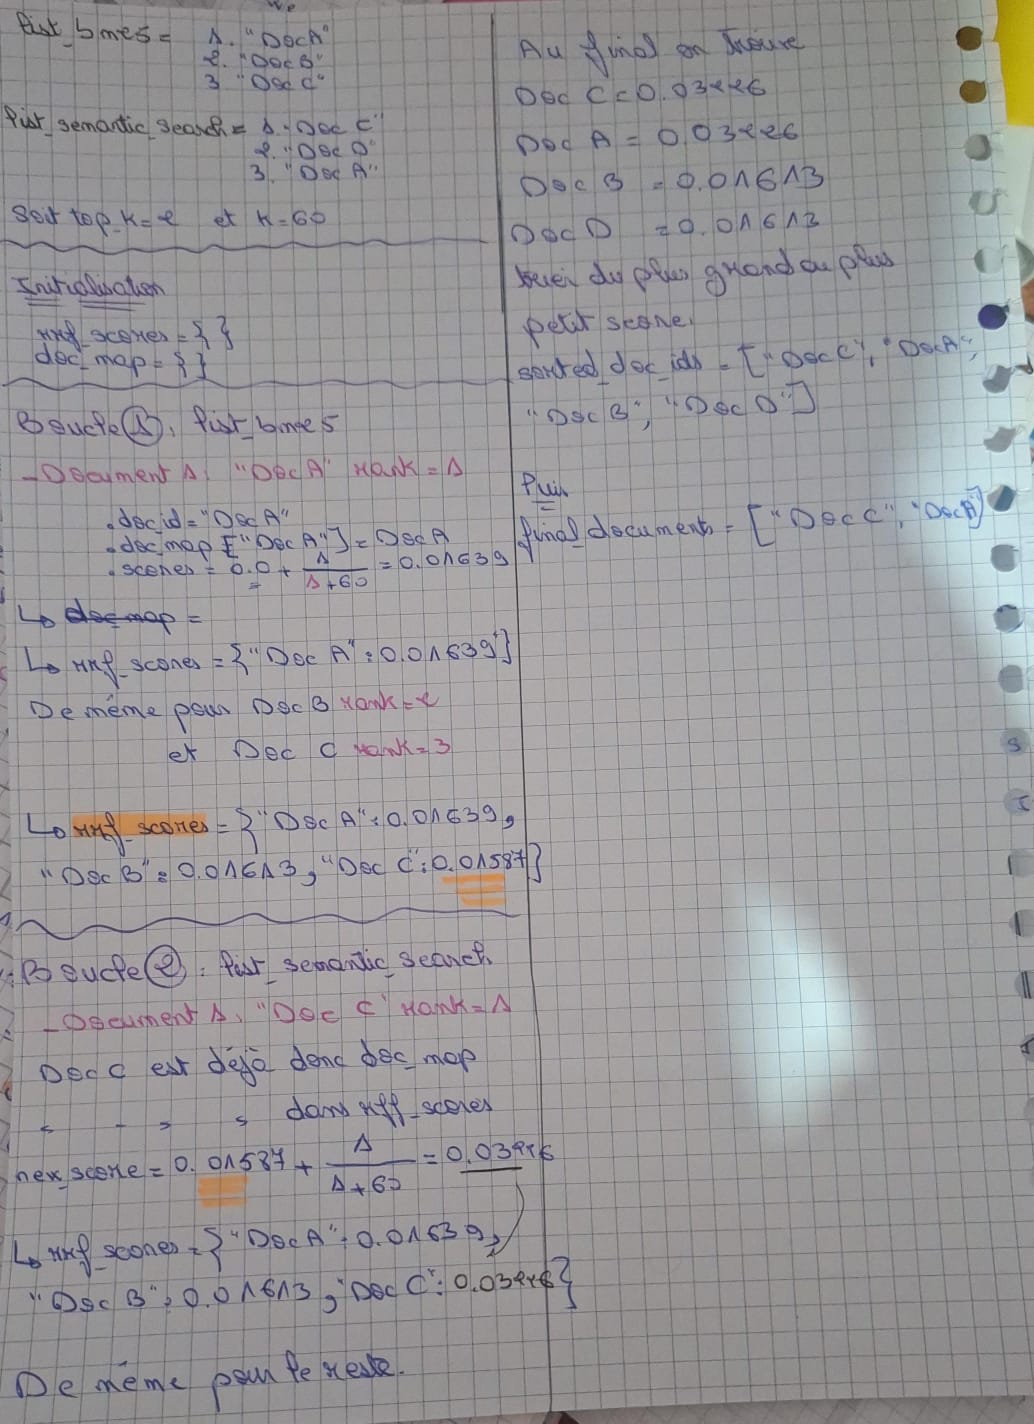

In [23]:
def reciprocal_rank_fusion(list_bm25: list, list_semantic_search: list, top_k= 5, k= 60): # k=60 est une constante de lissage utilisée dans la formule mathématique du RRF
    
    rrf_scores = dict()
    doc_map = dict()
    
    for lst in [list_bm25, list_semantic_search]: # on traite successivement list1, puis list2!
        for rank, doc in enumerate(lst, start= 1): # on recupére la position et le document pour chaque doc de la liste actuelle
                                                        # start = 1, on commence par 1 c'est à dire l'index du premier element de la liste = 1 est non pas 0
                                                        
            doc_id = doc.page_content
            
            if doc_id not in doc_map:
                doc_map[doc_id] = doc
                #print(f"list : {lst} | rank : {rank} | doc_map : {doc_map} | doc_id: {doc_id}\n")
                
            if doc_id not in rrf_scores:
                rrf_scores[doc_id] = 0.0
            rrf_scores[doc_id] += 1 / (rank + k )
            
    sorted_doc_ids = sorted(rrf_scores, key= rrf_scores.get, reverse= True) # la liste de tous les documents ordonnés
    
    final_documents = [doc_map[doc_id] for doc_id in sorted_doc_ids[:top_k]] # les 5 premiers documents
    
    return final_documents




In [24]:
list1 = bm25_docs
list2 = chroma_docs

rrf_list = reciprocal_rank_fusion(list1, list2)
print(f"--------- Semantic Search List de taille : {len(list1)} ----------:\n {list1}")
print(f"\n--------- BM25 List de taille : {len(list2)}---------:\n {list2}")
print(f"\n--------- RRF List de taille :  {len(rrf_list)} ---------:\n {rrf_list}")

--------- Semantic Search List de taille : 5 ----------:
 [Document(metadata={'source': 'Code du Travail Marocain', 'article_no': 'Article 152'}, page_content="Article 152 La salariée en état de grossesse attesté par certificat médical dispose d'un congé de maternité de quatorze semaines, sauf stipulations plus favorables dans le contrat de travail, la convention collective de travail ou le règlement intérieur."), Document(metadata={'article_no': 'Article 154', 'source': 'Code du Travail Marocain'}, page_content="Article 154 La salariée a le droit de suspendre le contrat de travail pendant une période qui commence sept semaines avant la date présumée de l'accouchement et se termine sept semaines après la date de celui-ci. Si un état pathologique, attesté par certificat mé dical comme résultant de la grossesse ou des couches, rend nécessaire le prolongement de la période de suspension du contrat, le congé de maternité est augmenté de la durée de cet état pathologique, sans pouvoir excéd

In [25]:
list1 = chroma_docs
list2 = bm25_docs

# Application du Reciprocal Rank Fusion (RRF)
rrf_docs = reciprocal_rank_fusion(list1, list2, top_k=5)

print(f"=== Nombre de documents fusionnés (RRF) : {len(rrf_docs)} ===\n")

for i, doc in enumerate(rrf_docs, start=1):
    print(i)
    article_name = doc.metadata.get('article_no', 'Inconnu')
    print(f"Rang {i} [{article_name}] : {doc.page_content[:150]}...\n")

=== Nombre de documents fusionnés (RRF) : 5 ===

1
Rang 1 [Article 152] : Article 152 La salariée en état de grossesse attesté par certificat médical dispose d'un congé de maternité de quatorze semaines, sauf stipulations pl...

2
Rang 2 [Article 154] : Article 154 La salariée a le droit de suspendre le contrat de travail pendant une période qui commence sept semaines avant la date présumée de l'accou...

3
Rang 3 [Article 156] : Article 156 En vue d'élever son enfant, la mère salariée peut s'abstenir de reprendre son emploi à l'expiration du délai de sept semaines suivant l'ac...

4
Rang 4 [Article 247] : Article 247 Si le congé annuel payé s'accompagne de la fermeture totale ou partielle de l'établissement, l'employeur doit en aviser l'agent cha rgé de...

5
Rang 5 [Article 269] : Article 269 Tout salarié a droit, à l'occasion de chaque naissance, à un congé de trois jours. Cette disposition s'applique en cas de reconnaissance p...



### 5. Hybrid search

In [26]:

from langchain_classic.retrievers import EnsembleRetriever

bm25_retriever = BM25Retriever.from_documents(documents)
bm25_retriever.k = 10

chroma_retriever = vector_store.as_retriever(search_kwargs={"k": 10})

# Recherche hybride 
hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, chroma_retriever],
    weights=[0.5, 0.5]
)
print(type(hybrid_retriever))

<class 'langchain_classic.retrievers.ensemble.EnsembleRetriever'>


Si des articles apparaissent dans les deux listes alors EnsembleRetriever les fusionne et va éliminer les doublons.

In [27]:
print(type(vector_store))

<class 'langchain_chroma.vectorstores.Chroma'>


In [28]:
# test

query = "Quelle est la durée de congé de maternité pour une femme enceinte ?"
rrf_docs = hybrid_retriever.invoke(query)

print(f"=== Résultats Fusionnés ({len(rrf_docs)} docs) ===\n")
for doc in rrf_docs:
    print(f"[{doc.metadata.get('article_no')}] : {doc.page_content[:150]}...\n")

=== Résultats Fusionnés (18 docs) ===

[Article 152] : Article 152 La salariée en état de grossesse attesté par certificat médical dispose d'un congé de maternité de quatorze semaines, sauf stipulations pl...

[Article 154] : Article 154 La salariée a le droit de suspendre le contrat de travail pendant une période qui commence sept semaines avant la date présumée de l'accou...

[Article 247] : Article 247 Si le congé annuel payé s'accompagne de la fermeture totale ou partielle de l'établissement, l'employeur doit en aviser l'agent cha rgé de...

[Article 156] : Article 156 En vue d'élever son enfant, la mère salariée peut s'abstenir de reprendre son emploi à l'expiration du délai de sept semaines suivant l'ac...

[Article 235] : Article 235 La durée du congé annuel payé est augmentée d'autant de jours qu'il y a de jours de fête payés et de jours fériés pendant la période du co...

[Article 269] : Article 269 Tout salarié a droit, à l'occasion de chaque naissance, à un congé de trois jo

### 6. Reranking

On classe les meilleurs résultats finaux en haut pour garantir la pertinence des résultats

In [ ]:
from langchain_classic.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_community.document_compressors import FlashrankRerank

compressor = FlashrankRerank(model="ms-marco-MiniLM-L-12-v2",top_n = 5) # on garde juste top 5 


final_retriever = ContextualCompressionRetriever(
    base_compressor = compressor,
    base_retriever = hybrid_retriever 
) 

ms-marco-MiniLM-L-12-v2.zip: 100%|██████████| 21.6M/21.6M [00:01<00:00, 19.2MiB/s]


In [30]:
type(final_retriever)

langchain_classic.retrievers.contextual_compression.ContextualCompressionRetriever

In [31]:
query = "Quelle est la durée de congé de maternité pour une femme enceinte ?"

final_docs = final_retriever.invoke(query)

print(f"=== Résultats finaux après RRF + Reranking ({len(final_docs)} docs) ===\n")

for i, doc in enumerate(final_docs, start=1):
    article = doc.metadata.get('article_no', 'N/A')
    score = doc.metadata.get('relevance_score', 'N/A')
    
    print(f"Rang {i} [{article}] (Score: {score}) :")
    print(f"{doc.page_content[:150]}...\n")

=== Résultats finaux après RRF + Reranking (5 docs) ===

Rang 1 [Article 232] (Score: 0.9299226403236389) :
Article 232 La durée du congé annuel payé est augmentée à raison d'un jour et demi de travail effectif par période entière, continue ou non, de cinq a...

Rang 2 [Article 247] (Score: 0.8900004029273987) :
Article 247 Si le congé annuel payé s'accompagne de la fermeture totale ou partielle de l'établissement, l'employeur doit en aviser l'agent cha rgé de...

Rang 3 [Article 235] (Score: 0.8399288654327393) :
Article 235 La durée du congé annuel payé est augmentée d'autant de jours qu'il y a de jours de fête payés et de jours fériés pendant la période du co...

Rang 4 [Article 154] (Score: 0.7010868787765503) :
Article 154 La salariée a le droit de suspendre le contrat de travail pendant une période qui commence sept semaines avant la date présumée de l'accou...

Rang 5 [Article 152] (Score: 0.6324281692504883) :
Article 152 La salariée en état de grossesse attesté par certificat 

In [32]:
# un autre modèle pour reraning
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_classic.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker

model = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-v2-m3")


compressor = CrossEncoderReranker(model=model, top_n=5)


final_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=hybrid_retriever
)
print(type(model))
print(type(compressor))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.27GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

<class 'langchain_community.cross_encoders.huggingface.HuggingFaceCrossEncoder'>
<class 'langchain_classic.retrievers.document_compressors.cross_encoder_rerank.CrossEncoderReranker'>


In [33]:
query = "Quelle est la durée de congé de maternité pour une femme enceinte ?"

final_docs = final_retriever.invoke(query)

print(f"=== Résultats finaux après RRF + Reranking ({len(final_docs)} docs) ===\n")

for i, doc in enumerate(final_docs, start=1):
    article = doc.metadata.get('article_no', 'N/A')
    score = doc.metadata.get('relevance_score', 'N/A')
    
    print(f"{doc.page_content[:150]}...\n")

=== Résultats finaux après RRF + Reranking (5 docs) ===

Article 152 La salariée en état de grossesse attesté par certificat médical dispose d'un congé de maternité de quatorze semaines, sauf stipulations pl...

Article 154 La salariée a le droit de suspendre le contrat de travail pendant une période qui commence sept semaines avant la date présumée de l'accou...

Article 156 En vue d'élever son enfant, la mère salariée peut s'abstenir de reprendre son emploi à l'expiration du délai de sept semaines suivant l'ac...

Article 269 Tout salarié a droit, à l'occasion de chaque naissance, à un congé de trois jours. Cette disposition s'applique en cas de reconnaissance p...

Article 153 Les salariées en cou ches ne peuvent être occupées pendant la période de sept semaines consécutives qui suivent l'accouchement. -65 - L'em...



Ce modèle est plus performant que le premier !

In [34]:
# CODE DE TEST AVANT LA VERSION FINALE
# DEJA IMPLEMENTE PAR DEFAUT DANS EnsembleRetriever !!!!!!!!!
"""#b. keyword search
def bm25_key_word_search(vector_store: Chroma, query: str) -> list:
    documents = convert_to_text(vector_store) # récupérer le text

    # bm25 retriever
    bm25_retriever = BM25Retriever.from_documents(documents= documents, k= 5)
    
    bm25_docs = bm25_retriever.invoke(query)
    
    return bm25_docs

# DEJA IMPLEMENTE PAR DEFAUT DANS EnsembleRetriever !!!!!!!!!

# 4. Semantic search 

def semantic_search(vector_store: Chroma, query:str) -> list:
    chroma_retriever = vector_store.as_retriever(search_kwargs= {"k": 5})
    
    chroma_docs = chroma_retriever.invoke(query)
    
    return chroma_docs"""

# DEJA IMPLEMENTE PAR DEFAUT DANS EnsembleRetriever !!!!!!!!!

# 5. RRF Scores
"""def reciprocal_rank_fusion(list_bm25: list, list_semantic_search: list, top_k= 5, k= 60):
    
    rrf_scores = dict()
    doc_map = dict()
    for lst in [list_bm25, list_semantic_search]:
        for rank, doc in enumerate(lst, start= 1):
            
            doc_id = doc.page_content
            
            if doc_id not in doc_map:
                doc_map[doc_id] = doc
                
            if doc_id not in rrf_scores:
                rrf_scores[doc_id] = 0.0
            rrf_scores[doc_id] += 1 / (rank + k )
            
    sorted_doc_ids = sorted(rrf_scores, key= rrf_scores.get, reverse= True)
    
    final_documents = [doc_map[doc_id] for doc_id in sorted_doc_ids[:top_k]]
    
    return final_documents"""
print()